# Cinemática Directa y Graficado 3D de un Robot a partir de su Tabla DH



## Paso 0 — Librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

## Paso 1 — Tabla DH del robot



In [ ]:
# Columnas: [alpha_{i-1}, a_{i-1}, theta_i, d_i, sigma_i]
tabla_dh = [
    [ np.pi/2, 0,    np.pi/2, 0,    1],
    [ 0,       0.33, 0,       0,    0],
    [ 0,       0.4,  0,       0,    0],
    [ np.pi/2, 0,    0,       0.16, 0],
    [-np.pi/2, 0,    0,       0,    0],
]

n_gdl = len(tabla_dh)
print(f'Grados de libertad detectados: {n_gdl}')

Grados de libertad detectados: 5


## Paso 1.5 — Ingresar la posición (valores articulares q)



In [ ]:
q = []
for i, fila in enumerate(tabla_dh, start=1):
    sigma = fila[4]
    if sigma == 0:
        grados = float(input(f'Ingresa el valor de theta_{i} en GRADOS (ej. 90): '))
        valor = np.radians(grados)  # se convierte a radianes automáticamente
    else:
        valor = float(input(f'Ingresa el valor de d_{i} en METROS (ej. 0.25): '))
    q.append(valor)

print('\nVector de variables articulares q (en radianes/metros) =', q)

Ingresa el valor de d_1 en METROS (ej. 0.25): 0.25
Ingresa el valor de theta_2 en GRADOS (ej. 90): 90
Ingresa el valor de theta_3 en GRADOS (ej. 90): 90
Ingresa el valor de theta_4 en GRADOS (ej. 90): 90
Ingresa el valor de theta_5 en GRADOS (ej. 90): 45

Vector de variables articulares q (en radianes/metros) = [0.25, np.float64(1.5707963267948966), np.float64(1.5707963267948966), np.float64(1.5707963267948966), np.float64(0.7853981633974483)]


## Paso 2 — Cinemática directa (matriz de transformación DH)



In [ ]:
def matriz_dh(alpha, a, theta, d):
    """Matriz de transformación homogénea DH modificada (Craig)."""
    ca, sa = np.cos(alpha), np.sin(alpha)
    ct, st = np.cos(theta), np.sin(theta)
    return np.array([
        [ct,      -st,      0,      a],
        [st*ca,   ct*ca,   -sa,   -sa*d],
        [st*sa,   ct*sa,    ca,    ca*d],
        [0,        0,        0,      1]
    ])


def cinematica_directa(tabla_dh, q):
    """Devuelve:
    - posiciones: posición (x,y,z) del origen de cada articulación (incluye la base)
    - transforms: la matriz de transformación T0_i acumulada hasta cada articulación (incluye la base)
    - T: la matriz de transformación final T0_n (base -> efector final)
    Funciona para cualquier número de filas en tabla_dh.
    """
    T = np.eye(4)
    posiciones = [T[:3, 3].copy()]
    transforms = [T.copy()]  # T0_0 = identidad (sistema de la base)
    for (alpha, a, theta_fijo, d_fijo, sigma), qi in zip(tabla_dh, q):
        theta = qi if sigma == 0 else theta_fijo
        d = qi if sigma == 1 else d_fijo
        T = T @ matriz_dh(alpha, a, theta, d)
        posiciones.append(T[:3, 3].copy())
        transforms.append(T.copy())
    return np.array(posiciones), transforms, T


posiciones, transforms, T_final = cinematica_directa(tabla_dh, q)

np.set_printoptions(precision=4, suppress=True)
print('Posición de cada articulación (x, y, z):')
print(posiciones)
print('\nMatriz de transformación final T0_n (base -> efector final):')
print(T_final)

Posición de cada articulación (x, y, z):
[[ 0.    0.    0.  ]
 [ 0.   -0.25  0.  ]
 [ 0.   -0.25  0.33]
 [-0.4  -0.25  0.33]
 [-0.56 -0.25  0.33]
 [-0.56 -0.25  0.33]]

Matriz de transformación final T0_n (base -> efector final):
[[ 0.7071  0.7071  0.     -0.56  ]
 [-0.7071  0.7071 -0.     -0.25  ]
 [-0.     -0.      1.      0.33  ]
 [ 0.      0.      0.      1.    ]]


## Paso 3 — Función para dibujar los ejes X, Y, Z de una articulación



In [ ]:
def plot_frame(ax, T, nombre, size=0.08):
    """Dibuja la terna de ejes X (rojo), Y (verde), Z (azul) de una articulación.

    ax     : eje 3D de matplotlib donde se dibuja
    T      : matriz de transformación homogénea 4x4 de la articulación (T0_i)
    nombre : etiqueta para identificar la articulación (ej. '0', '1', '2'...)
    size   : longitud de las flechas de los ejes
    """
    origen = T[:3, 3]
    R = T[:3, :3]  # submatriz de rotación (columnas = direcciones de los ejes X, Y, Z)

    colores_ejes = ['r', 'g', 'b']  # X=rojo, Y=verde, Z=azul
    etiquetas_ejes = ['x', 'y', 'z']

    for i in range(3):
        direccion = R[:, i] * size
        ax.quiver(origen[0], origen[1], origen[2],
                  direccion[0], direccion[1], direccion[2],
                  color=colores_ejes[i], arrow_length_ratio=0.2)
        punta = origen + direccion
        ax.text(punta[0], punta[1], punta[2], etiquetas_ejes[i], color=colores_ejes[i])

    ax.text(origen[0], origen[1], origen[2], f' {nombre}', color='black')


print('Función plot_frame lista.')

Función plot_frame lista.


## Paso 4 — Graficar el robot en 3D



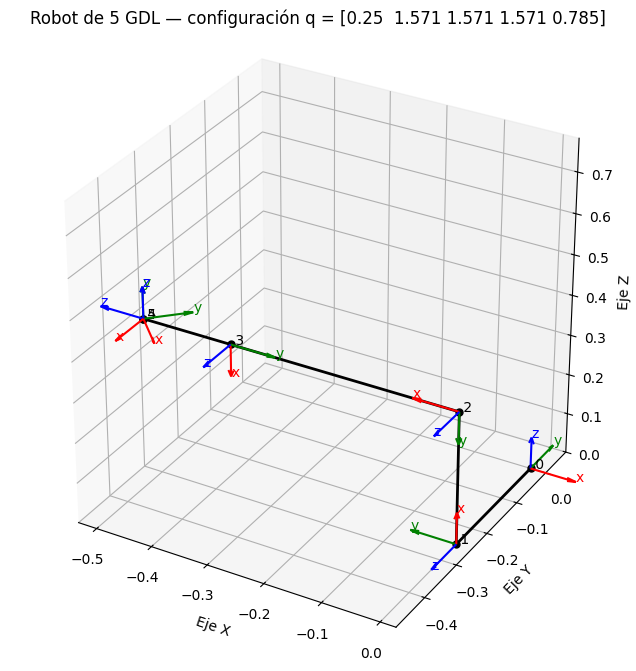

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Eslabones: línea que une el origen de cada articulación
ax.plot(posiciones[:, 0], posiciones[:, 1], posiciones[:, 2],
        '-o', color='black', linewidth=2, markersize=5)

# Ejes X, Y, Z de cada articulación (incluida la base, articulación '0')
for i, T in enumerate(transforms):
    plot_frame(ax, T, nombre=str(i), size=0.08)

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.set_title(f'Robot de {n_gdl} GDL — configuración q = {np.round(q, 3)}')

rango = max(np.ptp(posiciones, axis=0).max() / 2, 0.15)
centro = posiciones.mean(axis=0)
ax.set_xlim(centro[0]-rango, centro[0]+rango)
ax.set_ylim(centro[1]-rango, centro[1]+rango)
ax.set_zlim(0, centro[2]+2*rango)
ax.set_box_aspect([1, 1, 1])

plt.show()

## otra postura del robot



Ingresa el valor de d_1 en METROS (ej. 0.25): 0.3
Ingresa el valor de theta_2 en GRADOS (ej. 90): -80
Ingresa el valor de theta_3 en GRADOS (ej. 90): -10
Ingresa el valor de theta_4 en GRADOS (ej. 90): 0
Ingresa el valor de theta_5 en GRADOS (ej. 90): -70


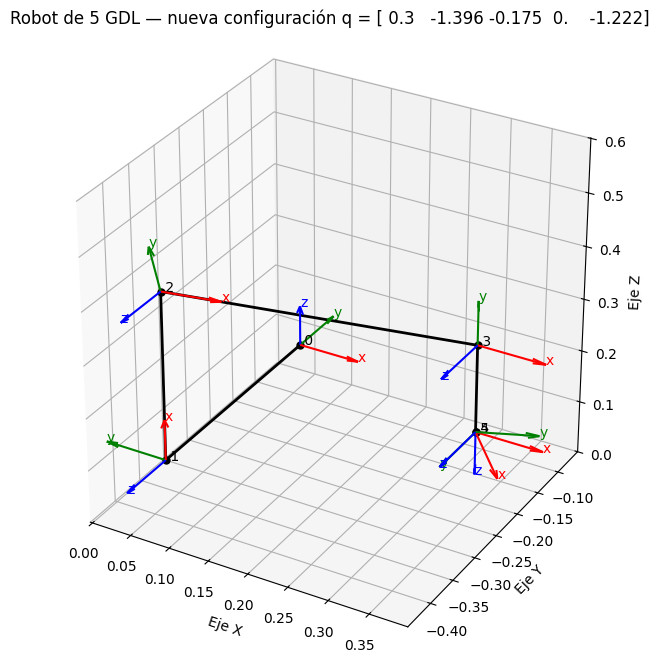

In [ ]:
q = []
for i, fila in enumerate(tabla_dh, start=1):
    sigma = fila[4]
    if sigma == 0:
        grados = float(input(f'Ingresa el valor de theta_{i} en GRADOS (ej. 90): '))
        valor = np.radians(grados)
    else:
        valor = float(input(f'Ingresa el valor de d_{i} en METROS (ej. 0.25): '))
    q.append(valor)

posiciones, transforms, T_final = cinematica_directa(tabla_dh, q)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(posiciones[:, 0], posiciones[:, 1], posiciones[:, 2], '-o', color='black', linewidth=2, markersize=5)
for i, T in enumerate(transforms):
    plot_frame(ax, T, nombre=str(i), size=0.08)
ax.set_xlabel('Eje X'); ax.set_ylabel('Eje Y'); ax.set_zlabel('Eje Z')
ax.set_title(f'Robot de {n_gdl} GDL — nueva configuración q = {np.round(q, 3)}')
rango = max(np.ptp(posiciones, axis=0).max() / 2, 0.15)
centro = posiciones.mean(axis=0)
ax.set_xlim(centro[0]-rango, centro[0]+rango)
ax.set_ylim(centro[1]-rango, centro[1]+rango)
ax.set_zlim(0, centro[2]+2*rango)
ax.set_box_aspect([1, 1, 1])
plt.show()

Ingresa el valor de d_1 en METROS (ej. 0.25): 0.25
Ingresa el valor de theta_2 en GRADOS (ej. 90): 45
Ingresa el valor de theta_3 en GRADOS (ej. 90): -45
Ingresa el valor de theta_4 en GRADOS (ej. 90): 90
Ingresa el valor de theta_5 en GRADOS (ej. 90): 0


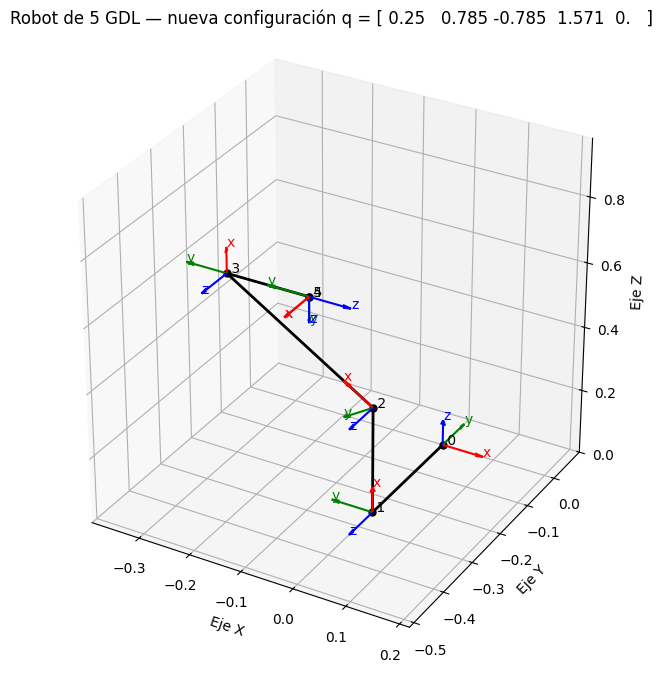

In [ ]:
q = []
for i, fila in enumerate(tabla_dh, start=1):
    sigma = fila[4]
    if sigma == 0:
        grados = float(input(f'Ingresa el valor de theta_{i} en GRADOS (ej. 90): '))
        valor = np.radians(grados)
    else:
        valor = float(input(f'Ingresa el valor de d_{i} en METROS (ej. 0.25): '))
    q.append(valor)

posiciones, transforms, T_final = cinematica_directa(tabla_dh, q)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(posiciones[:, 0], posiciones[:, 1], posiciones[:, 2], '-o', color='black', linewidth=2, markersize=5)
for i, T in enumerate(transforms):
    plot_frame(ax, T, nombre=str(i), size=0.08)
ax.set_xlabel('Eje X'); ax.set_ylabel('Eje Y'); ax.set_zlabel('Eje Z')
ax.set_title(f'Robot de {n_gdl} GDL — nueva configuración q = {np.round(q, 3)}')
rango = max(np.ptp(posiciones, axis=0).max() / 2, 0.15)
centro = posiciones.mean(axis=0)
ax.set_xlim(centro[0]-rango, centro[0]+rango)
ax.set_ylim(centro[1]-rango, centro[1]+rango)
ax.set_zlim(0, centro[2]+2*rango)
ax.set_box_aspect([1, 1, 1])
plt.show()